In [1]:
import os
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import numpy as np
from sklearn.model_selection import train_test_split

dataset_path = '/kaggle/input/gans-assign4/Dataset'

def load_images(folder_path, target_size=(250, 250), rotate_angle=-90):
    images = []
    labels = []
    label_mapping = {'0': 0, '1': 1}
    
    for label in os.listdir(folder_path):
        label_path = os.path.join(folder_path, label)
        label_value = label_mapping[label]
        
        for filename in os.listdir(label_path):
            img_path = os.path.join(label_path, filename)
            
            img = load_img(img_path, target_size=target_size)

            if label == '0':
                img = img.rotate(rotate_angle)
            
            img_array = img_to_array(img)
            
            img_array /= 255.0

            images.append(img_array)
            labels.append(label_value)
            
    return np.array(images), np.array(labels)

images, labels = load_images(dataset_path)
X_Train, X_Test, Y_Train, Y_Test = train_test_split(images, labels, test_size=0.2, shuffle=True)

In [2]:
import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
from keras import backend as K

original_dim = 250 * 250 * 3
intermediate_dim = 15000
latent_dim = 3000

inputs = keras.Input(shape=(original_dim,))
h = layers.Dense(intermediate_dim, activation='relu')(inputs)
z_mean = layers.Dense(latent_dim)(h)
z_log_sigma = layers.Dense(latent_dim)(h)

def sampling(args):
    z_mean, z_log_sigma = args
    epsilon = K.random_normal(shape=(K.shape(z_mean)[0], latent_dim), mean=0., stddev=0.1)
    return z_mean + K.exp(z_log_sigma) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_sigma])

encoder = keras.Model(inputs, z)

# Create decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(intermediate_dim, activation='relu')(latent_inputs)
outputs = layers.Dense(original_dim, activation='sigmoid')(x)
decoder = keras.Model(latent_inputs, outputs)

# VAE model
outputs = decoder(encoder(inputs))
vae = keras.Model(inputs, outputs)

reconstruction_loss = keras.losses.mean_squared_error(inputs, outputs)
reconstruction_loss *= original_dim
kl_loss = 1 + z_log_sigma - K.square(z_mean) - K.exp(z_log_sigma + 1e-8)
kl_loss = K.sum(kl_loss, axis=-1)
kl_loss *= -0.5
vae_loss = K.mean(reconstruction_loss + kl_loss)

vae.add_loss(vae_loss)
learning_rate = 0.00001
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
vae.compile(optimizer=optimizer, loss=None)

X_Train = X_Train.reshape((len(X_Train), np.prod(X_Train.shape[1:])))

vae.fit(X_Train, X_Train, epochs=30, batch_size=32)

2024-01-04 02:56:43.219596: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-01-04 02:56:43.219702: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-01-04 02:56:43.219778: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-01-04 02:56:43.219849: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-01-04 02:56:43.219943: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-01-04 02:56:43.220173: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-01-04 02:56:43.220256: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority un

Epoch 1/30
6/6 [==============================] - 188s 30s/step - loss: 11716.4990
Epoch 2/30
6/6 [==============================] - 186s 31s/step - loss: 11758.4150
Epoch 3/30
6/6 [==============================] - 180s 30s/step - loss: 12967.2500
Epoch 4/30
6/6 [==============================] - 180s 30s/step - loss: 11628.7373
Epoch 5/30
6/6 [==============================] - 185s 31s/step - loss: 11714.6494
Epoch 6/30
6/6 [==============================] - 187s 31s/step - loss: 11085.6162
Epoch 7/30
6/6 [==============================] - 186s 31s/step - loss: 9987.6475
Epoch 8/30
6/6 [==============================] - 188s 32s/step - loss: 9238.4658
Epoch 9/30
6/6 [==============================] - 183s 30s/step - loss: 10289.6484
Epoch 10/30
6/6 [==============================] - 188s 31s/step - loss: 8751.9639
Epoch 11/30
6/6 [==============================] - 187s 31s/step - loss: 8616.7891
Epoch 12/30
6/6 [==============================] - 187s 31s/step - loss: 8986.1963
Epoch 

1/1 [==============================] - 0s 221ms/step


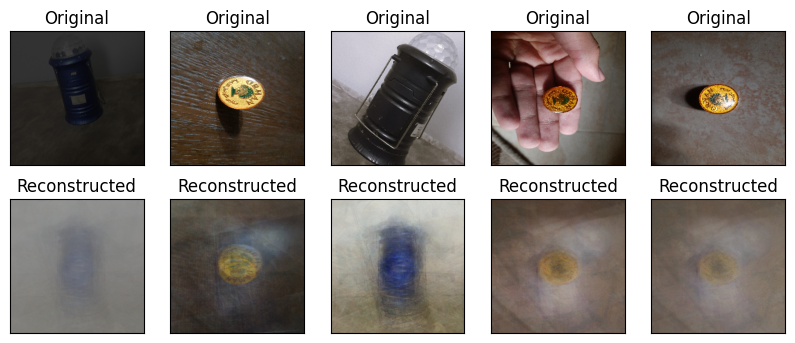

interactive(children=(IntSlider(value=5, description='No. of Imgs:', max=5, min=1), Output()), _dom_classes=('…

In [4]:
! pip install ipywidgets
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, widgets
from IPython.display import display

X_Test = X_Test.reshape((len(X_Test), np.prod(X_Test.shape[1:])))

encoder_output = encoder.predict(X_Test)

# Number of images to visualize
num_images = 5

def display_images_with_slider(num_images_to_display):
    num_images_to_display = int(num_images_to_display)

    original_images_to_display = X_Test[:num_images_to_display]

    reconstructed_images_to_display = decoder.predict(encoder_output[:num_images_to_display])

    n = len(original_images_to_display)
    plt.figure(figsize=(10, 4))

    for i in range(n):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original_images_to_display[i].reshape(250, 250, 3))
        plt.title('Original')
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed_images_to_display[i].reshape(250, 250, 3))
        plt.title('Reconstructed')
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()

images_slider = widgets.IntSlider(value=num_images, min=1, max=num_images, description='No. of Imgs:')
interact(display_images_with_slider, num_images_to_display=images_slider)

1/1 [==============================] - 0s 221ms/step


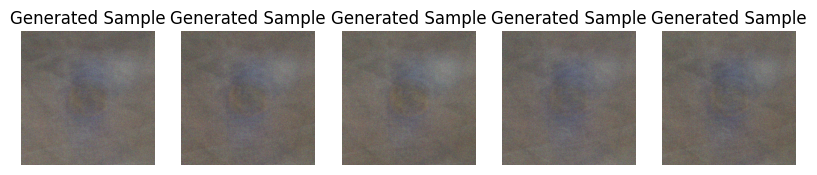

interactive(children=(IntSlider(value=5, description='No. of Imgs:', max=5, min=1), Output()), _dom_classes=('…

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# Generate samples using decoder_only
num_images = 5

def update_images(value):
    global num_images
    num_images = round(float(value))
    updated_generated_samples = decoder.predict(np.random.normal(size=(num_images, latent_dim)))
    display_images(updated_generated_samples)

def display_images(generated_samples):
    n = len(generated_samples)

    fig, axes = plt.subplots(1, n, figsize=(10, 2))

    for i in range(n):
        axes[i].imshow(generated_samples[i].reshape(250, 250, 3))
        axes[i].set_title('Generated Sample')
        axes[i].axis('off')

    plt.show()

images_slider = widgets.IntSlider(value=num_images, min=1, max=num_images, description='No. of Imgs:')
widgets.interactive(update_images, value=images_slider)